<a href="https://colab.research.google.com/github/ishwarihase/ML-projects/blob/main/sales_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
from google.colab import files

uploaded = files.upload()

Saving sales_data_sample.csv to sales_data_sample (1).csv


In [3]:
import os

print(os.listdir())

['.config', 'sales_data_sample.csv', 'sales_data_sample (1).csv', 'sample_data']


In [4]:
df = pd.read_csv("sales_data_sample.csv", encoding="latin-1")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2823, 25)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
features = ["QUANTITYORDERED", "PRICEEACH", "SALES"]

X = df[features]

print("Selected Features:")
print(X.head())

Selected Features:
   QUANTITYORDERED  PRICEEACH    SALES
0               30      95.70  2871.00
1               34      81.35  2765.90
2               41      94.74  3884.34
3               45      83.26  3746.70
4               49     100.00  5205.27


In [6]:
print("Missing Values:")
print(X.isnull().sum())

Missing Values:
QUANTITYORDERED    0
PRICEEACH          0
SALES              0
dtype: int64


In [7]:
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

print("Missing values handled successfully.")

Missing values handled successfully.


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

print("Scaled Data:")
print(X_scaled[:5])

Scaled Data:
[[-0.52289086  0.5969775  -0.37082523]
 [-0.11220131 -0.11445035 -0.42789707]
 [ 0.60650538  0.54938372  0.17944282]
 [ 1.01719493 -0.01975856  0.10470098]
 [ 1.42788447  0.81015797  0.89673966]]


In [9]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)

[8468.999999999982, 5091.753335644913, 3082.6505184877283, 2367.995702596403, 1927.895148581539, 1658.213887103111, 1447.9322063854297, 1281.4909346420109, 1172.5237680970886, 1073.1855484446446]


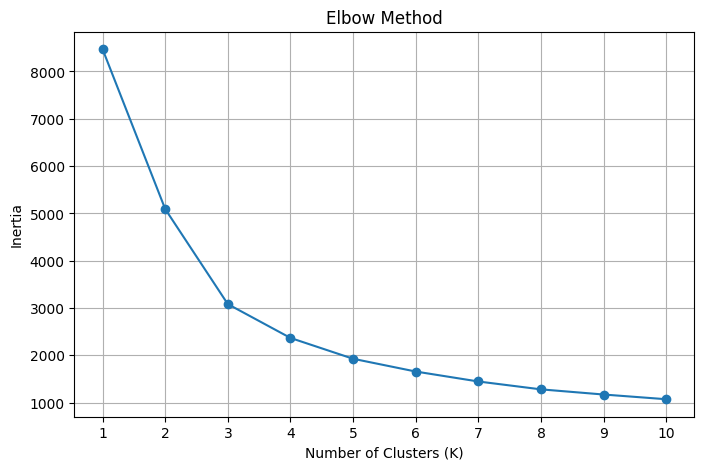

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [11]:
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means Clusters:")
print(kmeans_labels)

K-Means Clusters:
[2 2 1 ... 1 0 0]


In [12]:
df["KMeans_Cluster"] = kmeans_labels

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,KMeans_Cluster
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,2
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,2
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,1
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,1
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,1


In [13]:
print(df["KMeans_Cluster"].value_counts().sort_index())

KMeans_Cluster
0     881
1     907
2    1035
Name: count, dtype: int64


In [14]:
kmeans_summary = df.groupby("KMeans_Cluster")[features].mean()

print(kmeans_summary)

                QUANTITYORDERED  PRICEEACH        SALES
KMeans_Cluster                                         
0                     35.125993  57.130216  2009.829955
1                     43.847850  96.637795  5584.007299
2                     27.392271  94.865575  3089.153662


In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

PCA Shape: (2823, 2)
Explained Variance Ratio:
[0.62037653 0.33150716]


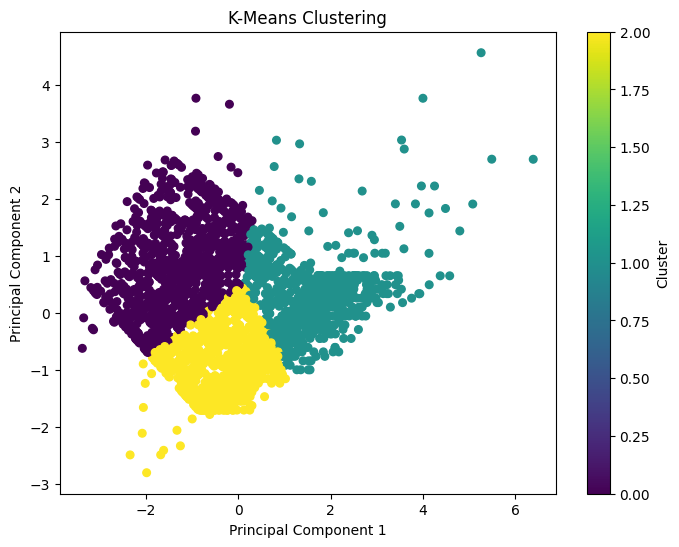

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=30
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering")

plt.colorbar(label="Cluster")

plt.show()

In [17]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

print("Hierarchical Clusters:")
print(hierarchical_labels)

Hierarchical Clusters:
[2 2 1 ... 1 0 0]


In [18]:
df["Hierarchical_Cluster"] = hierarchical_labels

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,KMeans_Cluster,Hierarchical_Cluster
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,NYC,NY,10022,USA,NaN,Yu,Kwai,Small,2,2
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small,2,2
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium,1,1
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium,1,0
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium,1,1


In [19]:
hierarchical_summary = df.groupby(
    "Hierarchical_Cluster"
)[features].mean()

print(hierarchical_summary)

                      QUANTITYORDERED  PRICEEACH        SALES
Hierarchical_Cluster                                         
0                           36.577909  60.350631  2238.072268
1                           44.083212  99.451168  6081.749635
2                           28.274021  95.060925  3200.378176


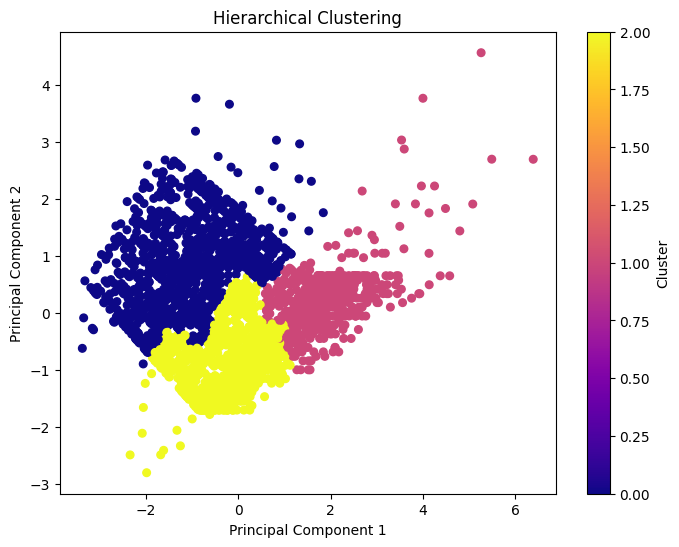

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    cmap="plasma",
    s=30
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering")

plt.colorbar(label="Cluster")

plt.show()

In [21]:
np.random.seed(42)

sample_size = min(120, len(X_scaled))

sample_index = np.random.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_index]

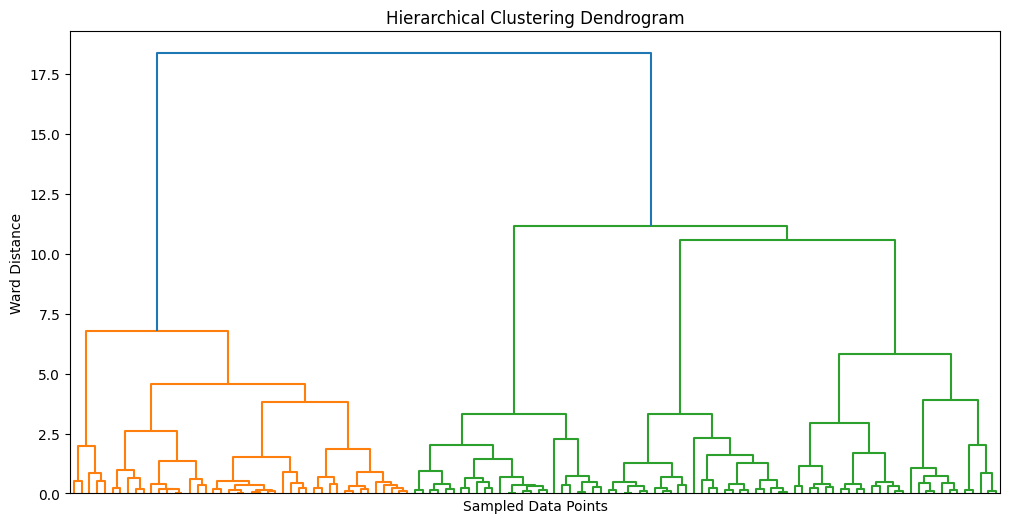

In [22]:
linked = linkage(
    X_sample,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    no_labels=True
)

plt.xlabel("Sampled Data Points")
plt.ylabel("Ward Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [23]:
print("Final Dataset with Clusters:")

df[
    features +
    ["KMeans_Cluster", "Hierarchical_Cluster"]
].head(20)

Final Dataset with Clusters:


,QUANTITYORDERED,PRICEEACH,SALES,KMeans_Cluster,Hierarchical_Cluster
0,30,95.70,2871.00,2,2
1,34,81.35,2765.90,2,2
2,41,94.74,3884.34,1,1
3,45,83.26,3746.70,1,0
4,49,100.00,5205.27,1,1
5,36,96.66,3479.76,2,2
6,29,86.13,2497.77,2,2
7,48,100.00,5512.32,1,1
8,22,98.57,2168.54,2,2
9,41,100.00,4708.44,1,1


In [24]:
df.to_csv(
    "sales_clustering_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [25]:
files.download("sales_clustering_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>